In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from numpy import exp, linspace, random, std, mean, log10, ceil, diag, sqrt, log

In [3]:
def exponencial(x, a, b):
    '''esta funcion retorna la funcion exponencial cuando
     se ingresa el array de la variable independiente y los valores
     de amplitud y el parametro que acompaña el exponnete'''
    
    return a*exp(b*x)

In [4]:
def linealizada(x, a, b):
    ''' 
    Esta funcion retorna la linealizacion de la funcion del 
    voltaje vs corriente en un diodo. '''

    return log(x)* a +b

# Datos delimitados de a 0.005

In [5]:
df =pd.read_csv('Datos/datos_de_fisica_experimental.csv', delimiter=';')

In [6]:
df['Corriente'] = df['Corriente']* 1e-4

In [7]:
I = df['Corriente']
V = df['Voltaje']
mejor_valor, cov = curve_fit(exponencial, V, I)

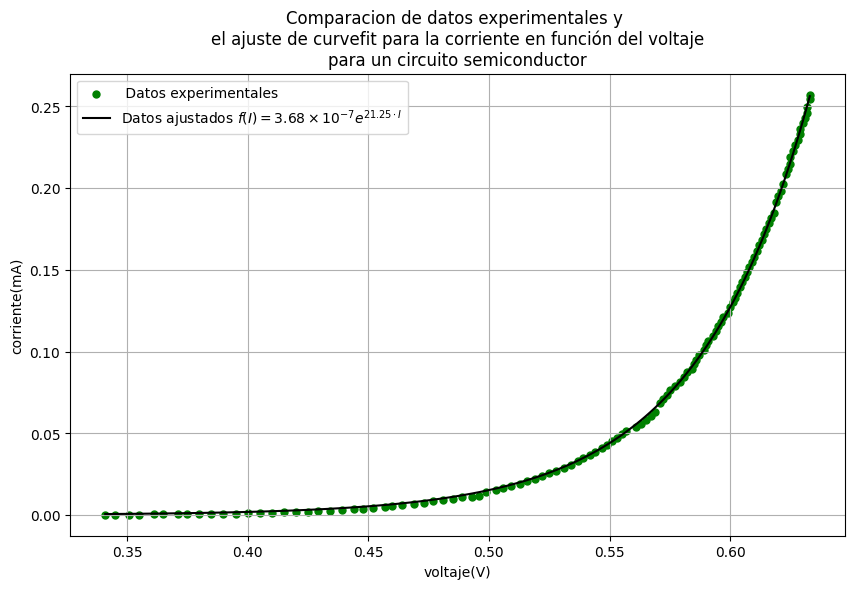

In [9]:
I = df['Corriente']
V = df['Voltaje']

Ia =exponencial(V, mejor_valor[0], mejor_valor[1])
plt.figure(figsize=(10,6))
plt.title('Comparacion de datos experimentales y \nel ajuste de curvefit para la corriente en función del voltaje\npara un circuito semiconductor')
plt.scatter(V, I, label = ' Datos experimentales', s = 25,c = 'green')
plt.plot(V, Ia,c= 'black', 
         label = f"Datos ajustados $f(I) = {mejor_valor[0]*1e7:.2f} \\times 10^{{-7}} e^{{{mejor_valor[1]:.2f} \\cdot I}}$")
plt.ylabel( 'corriente(mA)')
plt.xlabel('voltaje(V)')
plt.legend()
plt.grid()
plt.show()

In [10]:
display(diag(cov))

array([1.32164161e-16, 2.56269265e-03])

## Test de bondad de chicuadrado

5
0.0001 0.25720000000000004
[1.0000e-04 5.1520e-02 1.0294e-01 1.5436e-01 2.0578e-01 2.5720e-01]
[1.0000e-04 5.1520e-02 1.0294e-01 1.5436e-01 2.0578e-01 2.5720e-01]
[57. 18. 17. 14. 15.]
[57. 19. 17. 13. 15.]
Chi cuadrado = 0.12955465587044535


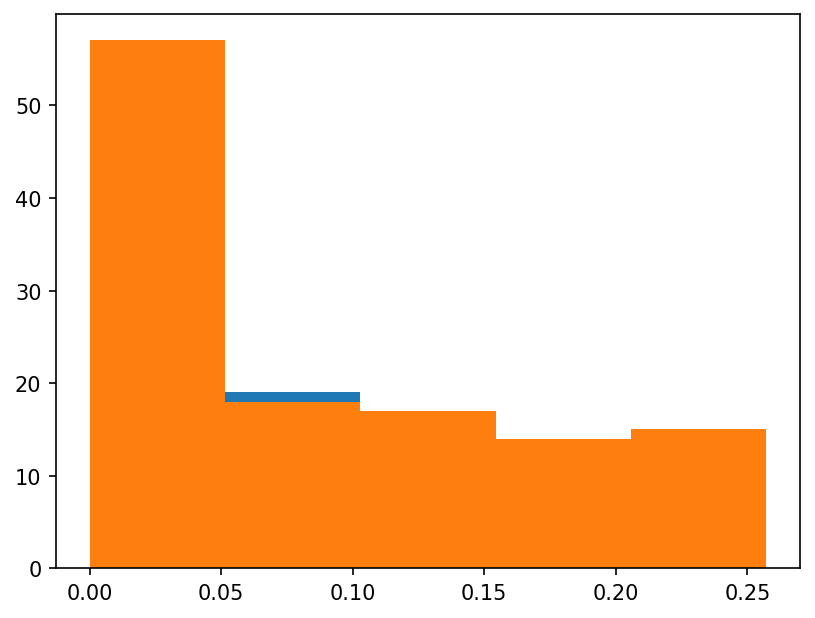

In [11]:
nbin = int(1 + 3.322 * log10(101)) - 2
print(nbin)

ymin1 = min(I)
ymin2 = min(Ia)
ymin = ymin2 if ymin1 > ymin2 else ymin1

ymax1 = max(I)
ymax2 = max(Ia)
ymax = ymax1 if ymax1 > ymax2 else ymax2
print(ymin, ymax)

plt.figure(dpi=150)
naj, baj, paj = plt.hist(Ia, bins=nbin, range=(ymin, ymax))
n, b, p = plt.hist(I, bins=nbin, range=(ymin, ymax))

print(b)
print(baj)
print(n)

def chi_sqr(dathistexp, dathistaj):
    return sum(((dathistexp - dathistaj) ** 2) / dathistaj)

print(naj)
print('Chi cuadrado =', chi_sqr(n, naj))

# Datos delimitados de a 0.01

In [ ]:
datos = pd.read_csv("Datos/datos de a 0.01.csv", delimiter=';')

In [ ]:
datos

,voltaje,corriente
0,411,13
1,420,18
2,439,23
3,447,29
4,456,38
...,...,...
82,666,5511
83,666,5601
84,667,5960
85,667,5779


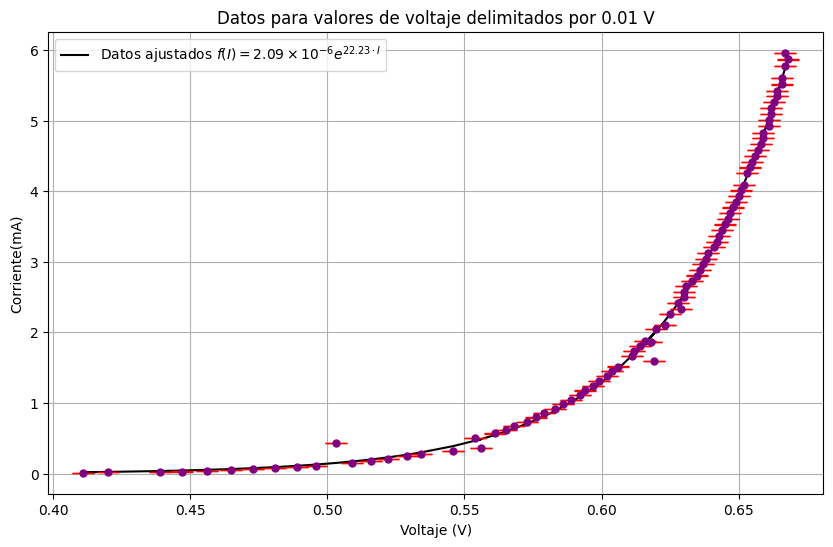

In [ ]:
I = datos['corriente']* 1e-3
V = datos['voltaje']* 1e-3
mejor_valor, cov = curve_fit(exponencial, V, I)
a = mejor_valor[0]
b = mejor_valor[1]

Ia = exponencial(V, a, b)

plt.figure(figsize=(10,6))
plt.title('Datos para valores de voltaje delimitados por 0.01 V')
# plt.scatter(V, I, c = 'purple', s = 25, label = 'Datos experimentales')
plt.plot(V, Ia, c = 'black', 
         label = f"Datos ajustados $f(I) = {a*1e6:.2f} \\times 10^{{-6}} e^{{{b:.2f} \\cdot I}}$")
plt.errorbar(V,I,yerr=1e-3,fmt='.',ms= 10,capsize=8,ecolor='r',color='purple')
plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente(mA)')
plt.grid()
plt.legend()
plt.show()

## Test de bondad de chicuadrado

5
0.013000000000000001 5.96
[0.013  1.2024 2.3918 3.5812 4.7706 5.96  ]
[0.013  1.2024 2.3918 3.5812 4.7706 5.96  ]
[30. 15. 15. 14. 13.]
[30. 14. 16. 13. 14.]
Chi cuadrado = 0.2822802197802198


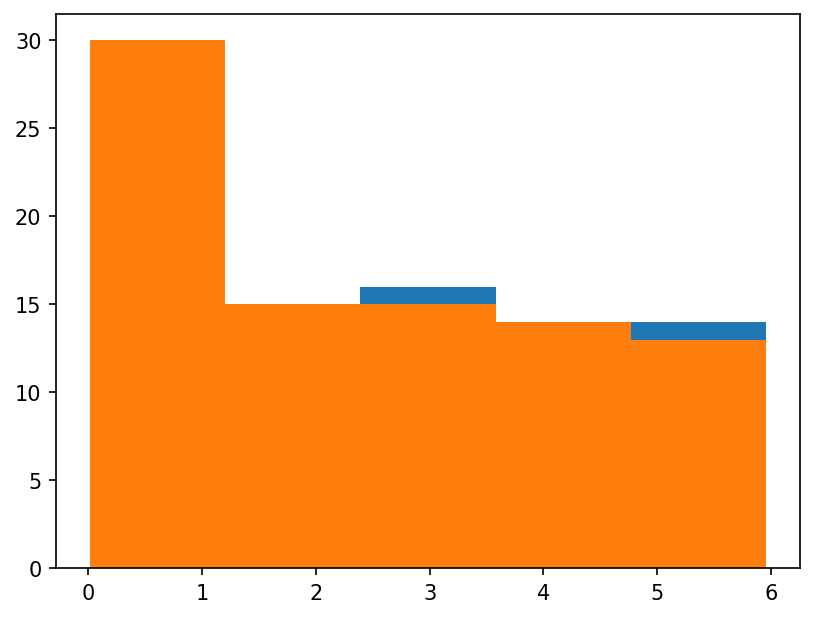

In [ ]:
nbin = int(1 + 3.322 * log10(101)) - 2
print(nbin)

ymin1 = min(I)
ymin2 = min(Ia)
ymin = ymin2 if ymin1 > ymin2 else ymin1

ymax1 = max(I)
ymax2 = max(Ia)
ymax = ymax1 if ymax1 > ymax2 else ymax2
print(ymin, ymax)

plt.figure(dpi=150)
naj, baj, paj = plt.hist(Ia, bins=nbin, range=(ymin, ymax))
n, b, p = plt.hist(I, bins=nbin, range=(ymin, ymax))

print(b)
print(baj)
print(n)

def chi_sqr(dathistexp, dathistaj):
    return sum(((dathistexp - dathistaj) ** 2) / dathistaj)

print(naj)
print('Chi cuadrado =', chi_sqr(n, naj))

In [ ]:
kb = 1.602176634e-19/(mejor_valor[1] * (23.8 + 273.15) * 1.91 )
print(kb)

1.2707031824994177e-23


# Datos delimitados de a 0.05

In [ ]:
datos1 = pd.read_csv('Datos/datos para datos tomados de a 0.05v.csv',delimiter= ';')

datos1 = datos1*1e-3
display(datos1)

,voltaje,corriente,voltaje 1,corriente 1,voltaje 2,corriente 2
0,0.400,0.002,0.351,0.002,0.351,0.002
1,0.446,0.038,0.400,0.010,0.400,0.010
2,0.496,0.129,0.448,0.039,0.446,0.039
3,0.528,0.275,0.482,0.091,0.489,0.111
4,0.550,0.438,0.523,0.244,0.523,0.245
5,0.565,0.667,0.555,0.492,0.550,0.447
6,0.586,0.943,0.570,0.686,0.570,0.689
7,0.598,1.235,0.587,0.970,0.585,0.968
8,0.609,1.542,0.600,1.273,0.600,1.272
9,0.618,1.871,0.611,1.592,0.610,1.592


In [ ]:
I = datos1['corriente'].dropna()
V = datos1['voltaje'].dropna()
I1 = datos1['corriente 1']
V1 = datos1['voltaje 1']
I2 = datos1['corriente 2']
V2 = datos1['voltaje 2']

mejor_valor, cov = curve_fit(linealizada,V, I)
mejor_valor1, cov1 = curve_fit(linealizada, I1, V1)
mejor_valor2, cov2 = curve_fit(linealizada, I2, V2)

a = mejor_valor[0]
b = mejor_valor[1]
a1 = mejor_valor1[0]
b1 = mejor_valor1[1]
a2 = mejor_valor2[0]
b2 = mejor_valor2[1]

L1 = linealizada(I, a, b)
L2 = linealizada(I1, a1, b1)
L3 = linealizada(I2, a2, b2)

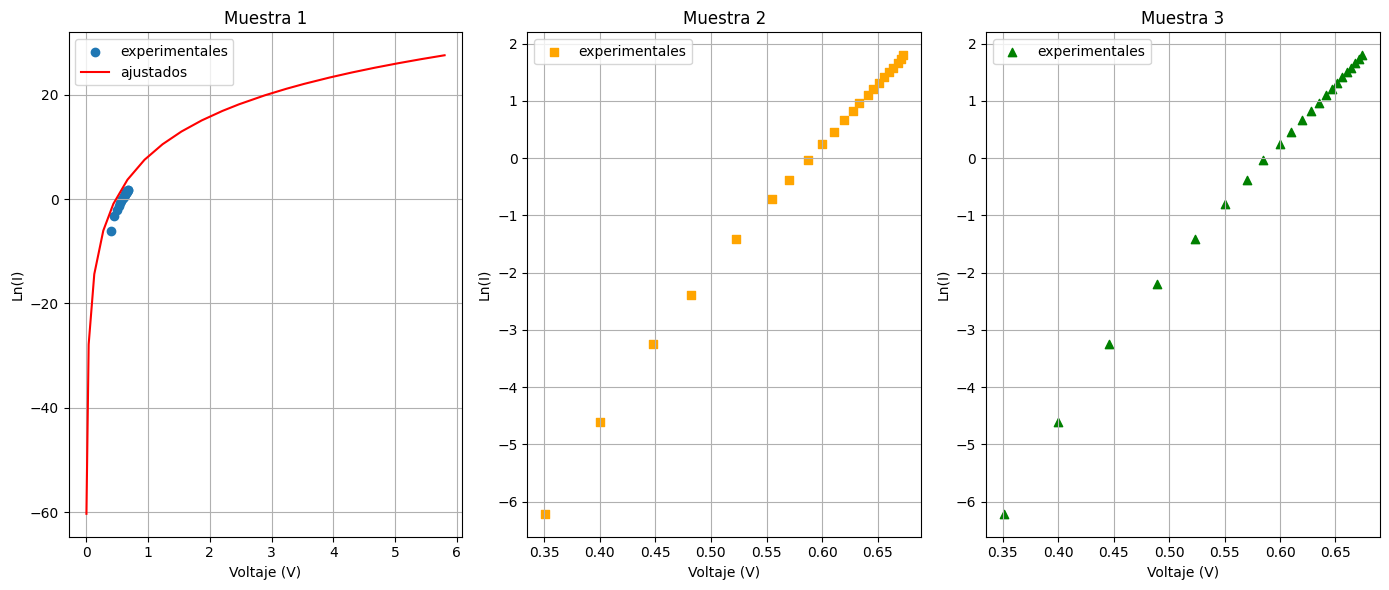

In [ ]:

plt.figure(figsize=(14,6))  # más ancho para 3 gráficas

# plt.title('Datos par valores de voltaje delimitados por 0.05 V')

# --- Gráfica 1 ---
plt.subplot(1,3,1)
plt.scatter(V, log(I), marker='o', label = 'experimentales')
plt.plot(I, L1, label = 'ajustados', color = 'red')
plt.title("Muestra 1")
plt.xlabel("Voltaje (V)")
plt.ylabel("Ln(I)")
plt.legend()
plt.grid(True)

# --- Gráfica 2 ---
plt.subplot(1,3,2)
plt.scatter(V1, log(I1), marker='s', color='orange', label = 'experimentales')
# plt.plot(I1, L2, label = 'ajustados')
plt.title("Muestra 2")
plt.xlabel("Voltaje (V)")
plt.ylabel("Ln(I)")
plt.legend()
plt.grid(True)

# --- Gráfica 3 ---
plt.subplot(1,3,3)
plt.scatter(V2, log(I2), marker='^', color='green', label = 'experimentales')
# plt.plot(I2, L3, label = 'ajustados')
plt.title("Muestra 3")
plt.xlabel("Voltaje (V)")
plt.ylabel("Ln(I)")
plt.legend()
plt.grid(True)

plt.tight_layout()  # ajusta espacios automáticamente
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8,4))

axs[0].scatter(x1, y1)
axs[0].set_title("Experimento 1", fontsize=10)

axs[1].scatter(x2, y2)
axs[1].set_title("Experimento 2", fontsize=10)

fig.suptitle("Comparación", fontsize=14)

plt.tight_layout()

In [ ]:
plt.subplot?

Signature: plt.subplot(*args, **kwargs) -> 'Axes'
Docstring:
Add an Axes to the current figure or retrieve an existing Axes.

This is a wrapper of `.Figure.add_subplot` which provides additional
behavior when working with the implicit API (see the notes section).

Call signatures::

   subplot(nrows, ncols, index, **kwargs)
   subplot(pos, **kwargs)
   subplot(**kwargs)
   subplot(ax)

Parameters
----------
*args : int, (int, int, *index*), or `.SubplotSpec`, default: (1, 1, 1)
    The position of the subplot described by one of

    - Three integers (*nrows*, *ncols*, *index*). The subplot will take the
      *index* position on a grid with *nrows* rows and *ncols* columns.
      *index* starts at 1 in the upper left corner and increases to the
      right. *index* can also be a two-tuple specifying the (*first*,
      *last*) indices (1-based, and including *last*) of the subplot, e.g.,
      ``fig.add_subplot(3, 1, (1, 2))`` makes a subplot that spans the
      upper 2/3 of the figu